<a href="https://colab.research.google.com/github/Oswvldo/GIS-Solutions-/blob/Data-conversion/DEM_to_KPKX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Start

# Data entry

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 3D_Tiles_fixed (1).py to 3D_Tiles_fixed (1).py


In [2]:
!pip install trimesh pyproj


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.3/709.3 kB 12.8 MB/s eta 0:00:00


# Modified script for **Colab**

In [3]:
import os
import requests
import gzip
import numpy as np
import trimesh
from pyproj import CRS

# --- PARAMETERS ---
tile_name = "N45W123"
url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/{tile_name[:3]}/{tile_name}.hgt.gz"
output_obj = "/content/terrain.obj"  # Changed for Colab
output_prj = "/content/terrain.prj"  # Changed for Colab

# --- 1) Download & decompress the HGT ---
print("Downloading elevation data...")
local_gz = f"/content/{tile_name}.hgt.gz"
local_hgt = f"/content/{tile_name}.hgt"

r = requests.get(url)
r.raise_for_status()
with open(local_gz, 'wb') as f: f.write(r.content)
with gzip.open(local_gz, 'rb') as f_in, open(local_hgt, 'wb') as f_out:
    f_out.write(f_in.read())
os.remove(local_gz)

# --- 2) Read the HGT ###
grid_size = 3601
print("Processing elevation data...")
dem = (np.fromfile(local_hgt, '>i2', grid_size**2)
         .reshape((grid_size, grid_size))
         .astype(np.float32))
dem[dem == -32768] = 0.0

# --- 3) Build lon/lat grids ###
# adjust these to match the tile
min_lon, max_lon = 74.0, 74.5
min_lat, max_lat = 33.5, 44.0
lons = np.linspace(min_lon, max_lon, grid_size)
lats = np.linspace(max_lat, min_lat, grid_size)
lon_g, lat_g = np.meshgrid(lons, lats)

# --- 4) Create vertices + faces ###
print("Generating 3D mesh...")
verts = np.column_stack((lon_g.ravel(),
                         lat_g.ravel(),
                         dem.ravel()))
faces = []
for i in range(grid_size-1):
    for j in range(grid_size-1):
        idx = i*grid_size + j
        faces.append([idx, idx+grid_size,     idx+grid_size+1])
        faces.append([idx, idx+grid_size+1,   idx+1])
faces = np.array(faces)

mesh = trimesh.Trimesh(vertices=verts, faces=faces)

# --- 5) Export to OBJ ###
print("Exporting OBJ file...")
obj_str = mesh.export(file_type='obj')
with open(output_obj, 'w') as f:
    f.write(obj_str)

# --- 6) (Optional) Write a .prj ###
crs = CRS.from_epsg(4326)   # or whatever your DEM is in
with open(output_prj, 'w') as f:
    f.write(crs.to_wkt())

print("\nDone!")
print("Download your files:")
print(f"!ls -lh /content/terrain.*")

Processing elevation data...
Generating 3D mesh...
Exporting OBJ file...

Done!
Download your files:
!ls -lh /content/terrain.*


In [4]:
!pip install requests numpy trimesh pyproj matplotlib pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 9.2 MB/s eta 0:00:00


# Download and process the elevation data (similar to before)

In [5]:
import os
import requests
import gzip
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from pyproj import CRS

# --- PARAMETERS ---
tile_name = "N45W123"
url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/{tile_name[:3]}/{tile_name}.hgt.gz"
local_gz = f"/content/{tile_name}.hgt.gz"
local_hgt = f"/content/{tile_name}.hgt"

# Download and decompress
if not os.path.exists(local_hgt):
    print("Downloading elevation data...")
    r = requests.get(url)
    r.raise_for_status()
    with open(local_gz, 'wb') as f: f.write(r.content)
    with gzip.open(local_gz, 'rb') as f_in, open(local_hgt, 'wb') as f_out:
        f_out.write(f_in.read())
    os.remove(local_gz)

# Read the HGT file
grid_size = 3601
dem = (np.fromfile(local_hgt, '>i2', grid_size**2)
         .reshape((grid_size, grid_size))
         .astype(np.float32))
dem[dem == -32768] = 0.0

# VISUALIZATON

## 2D Visualization with Matplotlib

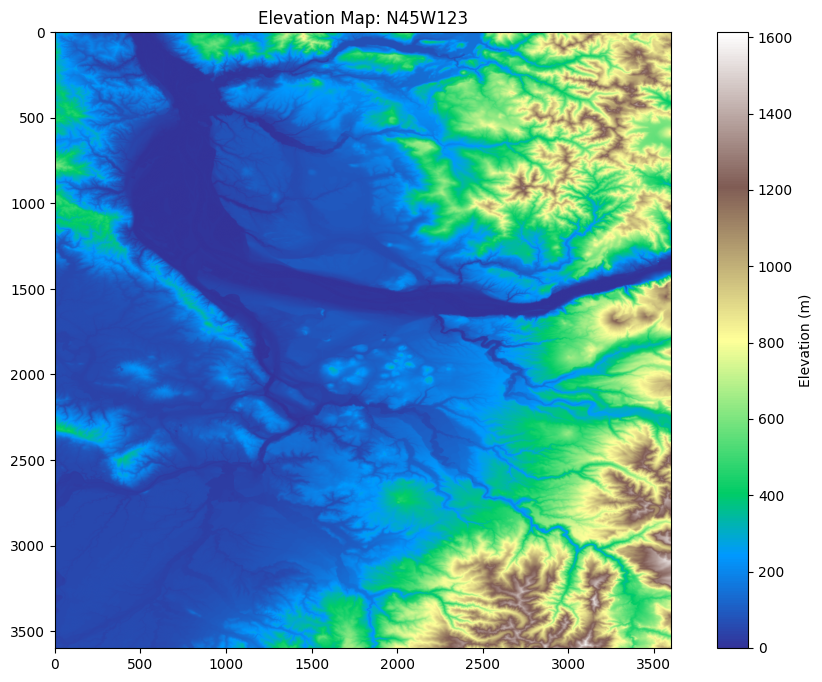

In [6]:
# Simple 2D visualization
plt.figure(figsize=(12, 8))
plt.imshow(dem, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title(f'Elevation Map: {tile_name}')
plt.show()

## 3D Interactive Visualization with PyVista

## For a more efficient visualization (downsampled)

In [8]:
# Downsample the data for better performance
downsample_factor = 20
dem_downsampled = dem[::downsample_factor, ::downsample_factor]

# Create the downsampled grid
x = np.linspace(0, 1, dem_downsampled.shape[1])
y = np.linspace(0, 1, dem_downsampled.shape[0])
xx, yy = np.meshgrid(x, y)

grid = pv.StructuredGrid(xx, yy, dem_downsampled/dem_downsampled.max())

# Interactive visualization
plotter = pv.Plotter()
plotter.add_mesh(grid, cmap='terrain', scalars=dem_downsampled.ravel(), name='terrain')
plotter.add_scalar_bar(title='Elevation (m)')
plotter.show(title=f'3D Terrain (Downsampled): {tile_name}')

## For a geographic coordinate system visualization

In [9]:
# Build lon/lat grids
min_lon, max_lon = -123.0, -122.0  # Adjusted for N45W123 tile
min_lat, max_lat = 45.0, 46.0
lons = np.linspace(min_lon, max_lon, grid_size)
lats = np.linspace(max_lat, min_lat, grid_size)
lon_g, lat_g = np.meshgrid(lons, lats)

# Downsample
lon_down = lon_g[::downsample_factor, ::downsample_factor]
lat_down = lat_g[::downsample_factor, ::downsample_factor]
dem_down = dem[::downsample_factor, ::downsample_factor]

# Create geographic grid
grid = pv.StructuredGrid(lon_down, lat_down, dem_down)

# Visualize
plotter = pv.Plotter()
plotter.add_mesh(grid, cmap='terrain', scalars=dem_down.ravel())
plotter.add_scalar_bar(title='Elevation (m)')
plotter.show(title='Geographic 3D Terrain')

In [12]:
!pip install plotly

import plotly.graph_objects as go

# Create figure
fig = go.Figure(data=[go.Surface(z=dem_downsampled, colorscale='Viridis')])

# Adjust layout
fig.update_layout(
    title=f'3D Terrain: {tile_name}',
    autosize=True,
    scene=dict(
        zaxis=dict(title='Elevation (m)'),
        aspectratio=dict(x=1, y=1, z=0.2)  # Adjust z-scale for better visualization
    )
)

fig.show()

# Using Python to convert DEM to KPKX

## Properly Install GDAL System Tools

In [14]:
# First install system GDAL tools
!sudo apt-get update
!sudo apt-get install -y gdal-bin

# Verify installation
!gdalinfo --version

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,701 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,607 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,864 kB]
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/u

## Process Your DEM Data

In [15]:
import os
import requests
import gzip

# --- Parameters ---
tile_name = "N45W123"
url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/{tile_name[:3]}/{tile_name}.hgt.gz"
local_gz = f"/content/{tile_name}.hgt.gz"
local_hgt = f"/content/{tile_name}.hgt"

# Download and decompress
if not os.path.exists(local_hgt):
    print("Downloading elevation data...")
    r = requests.get(url)
    r.raise_for_status()
    with open(local_gz, 'wb') as f:
        f.write(r.content)
    with gzip.open(local_gz, 'rb') as f_in, open(local_hgt, 'wb') as f_out:
        f_out.write(f_in.read())
    os.remove(local_gz)

# Convert to GeoTIFF with proper georeferencing
!gdal_translate -of GTiff -a_srs EPSG:4326 -a_ullr -123 46 -122 45 {local_hgt} /content/elevation.tif

# Add overviews for better performance
!gdaladdo -r average /content/elevation.tif 2 4 8 16

# Verify the output
!gdalinfo /content/elevation.tif

Input file size is 3601, 3601
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
Driver: GTiff/GeoTIFF
Files: /content/elevation.tif
Size is 3601, 3601
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["

## Install Required Tools

In [22]:
!sudo apt-get update
!sudo apt-get install -y gdal-bin python3-gdal zip
!pip install rasterio numpy

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

## Convert HGT to Proper GeoTIFF

In [23]:
import numpy as np
import rasterio
from rasterio.transform import from_origin

# Define parameters for N45W123 tile
west, north = -123, 46  # Tile bounding coordinates
resolution = 0.000833333  # ~90m resolution (3601px for 1°)

# Read HGT file
with open('/content/N45W123.hgt', 'rb') as f:
    dem = np.fromfile(f, dtype='>i2').reshape(3601, 3601).astype(np.float32)
    dem[dem == -32768] = np.nan  # Set null values

# Create georeferenced TIFF
with rasterio.open(
    '/content/elevation.tif',
    'w',
    driver='GTiff',
    height=dem.shape[0],
    width=dem.shape[1],
    count=1,
    dtype=dem.dtype,
    crs='EPSG:4326',
    transform=from_origin(west, north, resolution, -resolution),
    nodata=np.nan
) as dst:
    dst.write(dem, 1)

### Create TPKX Structure

In [24]:
# Create tile pyramid (zoom levels 0-14)
!mkdir -p /content/tpkx/tiles
!gdal2tiles.py -z 0-14 -p raster -w none /content/elevation.tif /content/tpkx/tiles/

# Create required metadata files
conf_content = """{
  "cacheInfo": {
    "storageInfo": {
      "packetSize": 128,
      "format": "COMPACT"
    }
  }
}"""

!echo '{conf_content}' > /content/tpkx/conf.json
!echo 'tpkx' > /content/tpkx/_alllayers

Usage: gdal2tiles.py [options] input_file [output]

gdal2tiles.py: error: Please convert this file to 8-bit and run gdal2tiles on the result.


To scale pixel values you can use:
gdal_translate -of VRT -ot Byte -scale /content/elevation.tif temp.vrt
then run:
gdal2tiles temp.vrt


## Package as TPKX

In [25]:
# Compress with correct structure
!cd /content/tpkx && zip -r ../elevation.tpkx *

# Verify package structure
!unzip -l /content/elevation.tpkx | head -15

  adding: _alllayers (stored 0%)
  adding: conf.json (deflated 27%)
  adding: tiles/ (stored 0%)
Archive:  /content/elevation.tpkx
  Length      Date    Time    Name
---------  ---------- -----   ----
        5  2025-04-28 15:51   _alllayers
      103  2025-04-28 15:51   conf.json
        0  2025-04-28 15:51   tiles/
---------                     -------
      108                     3 files


## Create TPKX Using GDAL Commands

In [20]:
# Create a virtual raster (VRT) first
!gdalbuildvrt /content/elevation.vrt /content/elevation.tif

# Generate tiles in TPKX-compatible format
!mkdir /content/tiles
!gdal2tiles.py -p raster -z 0-14 -w none /content/elevation.vrt /content/tiles/

# Package as ZIP (ArcGIS can import this)
!zip -r /content/elevation_tpkx.zip /content/tiles/

# Download
from google.colab import files
files.download('/content/elevation_tpkx.zip')

0...10...20...30...40...50...60...70...80...90...100 - done.
Usage: gdal2tiles.py [options] input_file [output]

gdal2tiles.py: error: Please convert this file to 8-bit and run gdal2tiles on the result.


To scale pixel values you can use:
gdal_translate -of VRT -ot Byte -scale /content/elevation.vrt temp.vrt
then run:
gdal2tiles temp.vrt
  adding: content/tiles/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

END